In [5]:
import pandas as pd
df = pd.read_csv("Raw_data/anonymized_clinical.csv")

Exploring the Dataset:

In [6]:
# Explore the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  20000 non-null  object 
 1   TIME_FROM_TX_TO_ASSESSMENT  20000 non-null  object 
 2   ANONYM_ASSESSMENT_DATE      20000 non-null  object 
 3   BP_SYSTOLIC_mmHG            19321 non-null  float64
 4   BP_DIASTOLIC_mmHg           19319 non-null  float64
 5   TEMPERATUR_DEG              6356 non-null   float64
 6   PULSE_PER_MIN               18734 non-null  float64
 7   URINE_VOL_L                 13600 non-null  float64
 8   REC_WT_KG                   19764 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.4+ MB


,BP_SYSTOLIC_mmHG,BP_DIASTOLIC_mmHg,TEMPERATUR_DEG,PULSE_PER_MIN,URINE_VOL_L,REC_WT_KG
count,19321.000000,19319.000000,6356.000000,18734.000000,13600.000000,19764.000000
mean,134.451478,82.425488,35.998932,74.072328,2310.857868,72.340434
std,17.421327,11.537038,0.431339,12.486655,658.561112,15.521993
min,75.000000,10.000000,34.000000,36.000000,0.000000,5.000000
25%,123.000000,75.000000,35.900000,65.000000,1900.000000,60.200000
50%,133.000000,82.000000,36.000000,72.000000,2200.000000,71.000000
75%,144.000000,90.000000,36.100000,81.000000,2700.000000,82.000000
max,243.000000,183.000000,42.000000,183.000000,7500.000000,168.000000


**Variable Normal Range (in Adults)**

BP_SYSTOLIC_mmHG 90–120 mmHg 

* Values between 120–129 are often considered "elevated."

BP_DIASTOLIC_mmHg 60–80 mmHg

* Consistent readings above 80 typically indicate hypertension.

TEMPERATUR_DEG 36.1°C – 37.2°C

* Varies by time of day and site.

PULSE_PER_MIN 60–100 BPM 

* Highly trained athletes may have resting rates as low as 40 BPM.

URINE_VOL_L0.8–2.0 L per day

* Based on a standard fluid intake of 2 liters over 24 hours.

**Medical Context**

These patients are on immunosuppressive therapy and have one functioning kidney, small fluctuations can be clinically significant.

1. **Fluid Balance & Graft Function**

*URINE_VOL_L (Urine Output)*: In the early post-transplant phase, a sudden drop in volume (*oliguria*) is a critical warning sign of potential rejection, dehydration, or vascular complications.

Conversely, extremely high volume (*polyuria*) is common immediately after surgery as the new kidney "wakes up."

*REC_WT_KG (Weight)*: Rapid weight gain (e.g., >1–2 kg in 24 hours) is often the first sign of fluid retention due to graft dysfunction, rather than actual fat or muscle gain.

2. **Cardiovascular & Hemodynamic Stability**

*BP_SYSTOLIC & BP_DIASTOLIC*: Hypertension is both a cause and a consequence of graft dysfunction. Many protocols aim for < 130/80 mmHg.

Note: High blood pressure can damage the delicate vasculature of the new graft, while very low blood pressure (hypotension) can lead to poor perfusion of the kidney.

*PULSE_PER_MIN*: Tachycardia (high heart rate) can be a non-specific sign of pain, dehydration, or systemic infection—all of which require immediate attention in an immunosuppressed patient.

3. **Infection & Rejection Monitoring**

*TEMPERATUR_DEG*: Because transplant recipients take immunosuppressants, their immune response is blunted. A "mild" fever ($37.8^{\circ}\text{C}$ or $100^{\circ}\text{F}$) that might be ignored in a healthy person can indicate a serious opportunistic infection or an acute rejection episode in a transplant patient.

In [7]:
# Check the number of duplicated dates of visit per patient
duplicate_visits = df.duplicated(subset=['Patient_ID', 'ANONYM_ASSESSMENT_DATE'], keep=False)
print(f"Number of duplicated visits: {duplicate_visits.sum()}")

Number of duplicated visits: 6967


These duplications in dates might mean the visits of each patient per month are recorded in the same date (first day of the month). And multiple visits per month might be relevant to the health status and hidden variables for the patient as the clinical reasoning isn't mentioned.

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Patient_ID                        0
TIME_FROM_TX_TO_ASSESSMENT        0
ANONYM_ASSESSMENT_DATE            0
BP_SYSTOLIC_mmHG                679
BP_DIASTOLIC_mmHg               681
TEMPERATUR_DEG                13644
PULSE_PER_MIN                  1266
URINE_VOL_L                    6400
REC_WT_KG                       236
dtype: int64


Temperature and Urine volume have +6000 missing values each. I checked the reasons of these missings but I didn't find any consistent pattern. This means that they could be MCAR (Missing Completely at Random) which means the missingness is a "glitch" (e.g., a sensor failure or a lost paper form). So, the missing values could be replaced by mean or median.

Or it could be MAR (Missing at Random) which means the missingness depends on other observed variables. (e.g., Temperature is missing more often for stable outpatients than for hospitalized ones). As I don't have more information except the vital signs and the number of days after transplantation which didn't show pattern, I decided to use iterative imputation to fill these values.

In [9]:
# If cell is empty, convert it to NaN
df.replace('', pd.NA, inplace=True)

# Check the missing values for each Patient_ID
missing_values_by_patient = df.groupby('Patient_ID').apply(lambda x: x.isnull().sum())
print(missing_values_by_patient)

# Count the number of Patient_IDs with 0 missing values
complete_cases = missing_values_by_patient[missing_values_by_patient.sum(axis=1) == 0].shape[0]
print(f"Number of Patient_IDs with complete data: {complete_cases}")

# Count the number of Patient_IDs with full missing values for each column 
# (Column missing values for this patient = the number of rows of this patient_ID),
# and mention which column is it for each case
full_missing_cases = {}
for column in df.columns:
    full_missing = missing_values_by_patient[column] == df.groupby('Patient_ID').size()
    full_missing_cases[column] = full_missing.sum()
print("Number of Patient_IDs with full missing values for each column:")
for column, count in full_missing_cases.items():
    print(f"{column}: {count}")

            Patient_ID  TIME_FROM_TX_TO_ASSESSMENT  ANONYM_ASSESSMENT_DATE  \
Patient_ID                                                                   
P1000                0                           0                       0   
P1001                0                           0                       0   
P1002                0                           0                       0   
P1003                0                           0                       0   
P1004                0                           0                       0   
...                ...                         ...                     ...   
P1307                0                           0                       0   
P1308                0                           0                       0   
P1309                0                           0                       0   
P1310                0                           0                       0   
P1311                0                           0              

Before imputation, I try to find:

Number of Patient_IDs with complete data = 0
Number of Patient_IDs with full missing values for each column = 0

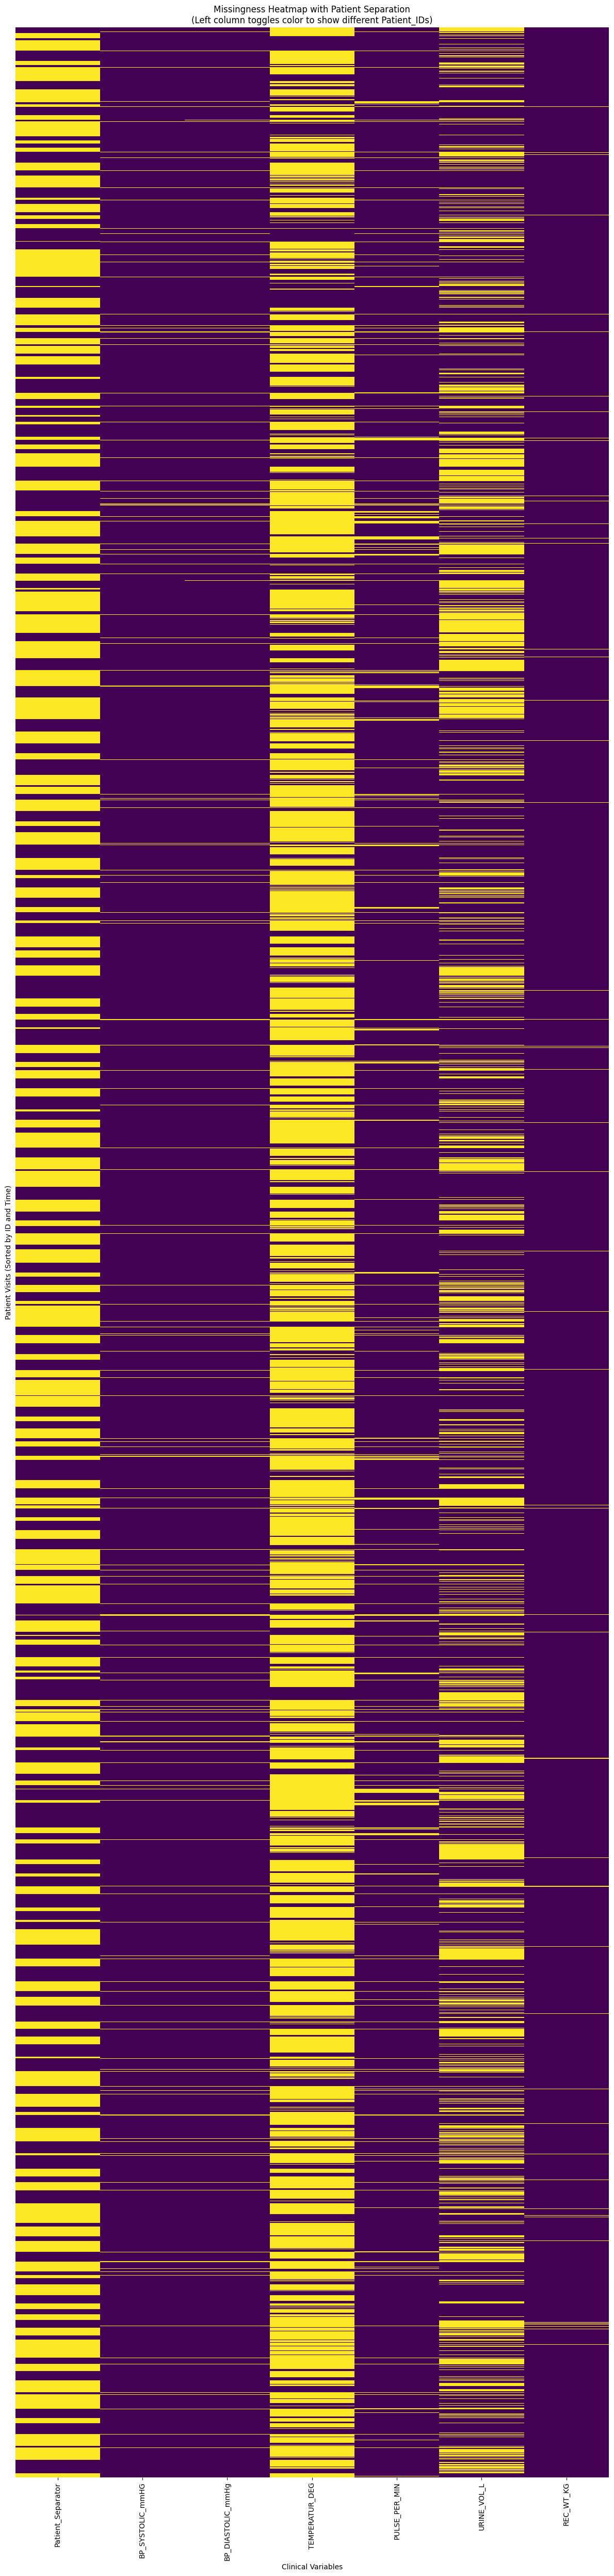

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Standardize and Sort
df['TIME_FROM_TX_TO_ASSESSMENT'] = df['TIME_FROM_TX_TO_ASSESSMENT'].astype(str).str.replace(' days', '').astype(float)
df_sorted = df.sort_values(by=['Patient_ID', 'TIME_FROM_TX_TO_ASSESSMENT']).copy()

# 2. Create the "Alternating Patient" helper column
# This identifies unique patients and assigns them an alternating 0 or 1
unique_patients = df_sorted['Patient_ID'].unique()
patient_map = {pid: i % 2 for i, pid in enumerate(unique_patients)}
df_sorted['Patient_Separator'] = df_sorted['Patient_ID'].map(patient_map)

# 3. Create the Matrix for the Heatmap
# We combine the "Separator" column with the "Missingness" boolean mask
# We use .isnull() for clinical data, but keep the 0/1 values for the separator
heatmap_data = df_sorted[['Patient_Separator']].copy()
clinical_cols = [
    'BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG', 
    'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG'
]
for col in clinical_cols:
    heatmap_data[col] = df_sorted[col].isnull().astype(int)

# 4. Plot
plt.figure(figsize=(12, 50))
sns.heatmap(heatmap_data, cbar=False, cmap='viridis', yticklabels=False)

plt.title('Missingness Heatmap with Patient Separation\n(Left column toggles color to show different Patient_IDs)')
plt.xlabel('Clinical Variables')
plt.ylabel('Patient Visits (Sorted by ID and Time)')
plt.tight_layout()
plt.show()

My observations are:
- Systolic and diastolic have *identical* horizontal yellow lines.

These are not missing independently. They are missing because of an event (the clinical visit didn't include a blood pressure measurement). If the missingness can be explained by the "Measurement Event" or the "Visit Type," it is MAR.

*Later, I noticed the absence of specific measures in old dates, might be relevant to the availability of the measuring device itself.*

- The variables temperature and urin volume show *dense blocks* of yellow.

If this were MCAR, the yellow dots would be scattered across the whole chart. Instead, we see long blocks of purple (data present) followed by long lines of yellow.

- Pulse and weight have very thin yellow lines, might be totally random missings.

All of this indicates the absence might be MAR, so imputation could be the best solution for it.

Cleaning:

As there is a significant number of missing values, we will need to handle them before proceeding with any analysis. We can consider options such as imputation as dropping rows (complete case) could remove more than 30% of the dataset.

In [ ]:
# I impute using IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Remove the cleaned file
import os
if os.path.exists("Cleaned_data/cleaned_KGENE.csv"):
    os.remove("Cleaned_data/cleaned_KGENE.csv")


# Select only numeric columns for imputation, rounding the imputed values to 2 decimal places
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
imputer = IterativeImputer(random_state=0)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
df[numeric_cols] = df[numeric_cols].round(2)

# Checking the dataset again after imputation
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  20000 non-null  object 
 1   TIME_FROM_TX_TO_ASSESSMENT  20000 non-null  float64
 2   ANONYM_ASSESSMENT_DATE      20000 non-null  object 
 3   BP_SYSTOLIC_mmHG            20000 non-null  float64
 4   BP_DIASTOLIC_mmHg           20000 non-null  float64
 5   TEMPERATUR_DEG              20000 non-null  float64
 6   PULSE_PER_MIN               20000 non-null  float64
 7   URINE_VOL_L                 20000 non-null  float64
 8   REC_WT_KG                   20000 non-null  float64
dtypes: float64(7), object(2)
memory usage: 1.4+ MB
None


In [12]:
# Comparison of the mean values of the vital signs across patients before and after imputation
# Read the original dataset for comparison
original_df = pd.read_csv("Raw_data/anonymized_clinical.csv")

# Calculate mean values of vital signs before imputation
vital_signs = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG','PULSE_PER_MIN', 'URINE_VOL_L','REC_WT_KG']
mean_before_imputation = original_df[vital_signs].mean()

# Calculate mean values of vital signs after imputation
mean_after_imputation = df[vital_signs].mean()

# Calculate the difference in standard deviation before and after imputation
std_before_imputation = original_df[vital_signs].std()
std_after_imputation = df[vital_signs].std()
difference_in_std = std_after_imputation - std_before_imputation

# Create a DataFrame for comparison adding additional column for difference
comparison_df = pd.DataFrame({
    'Vital_Sign': vital_signs,
    'Mean_Before_Imputation': mean_before_imputation.values,
    'Mean_After_Imputation': mean_after_imputation.values
})
comparison_df['Difference'] = comparison_df['Mean_After_Imputation'] - comparison_df['Mean_Before_Imputation']
print(comparison_df)
print(difference_in_std)


          Vital_Sign  Mean_Before_Imputation  Mean_After_Imputation  \
0   BP_SYSTOLIC_mmHG              134.451478             134.470949   
1  BP_DIASTOLIC_mmHg               82.425488              82.445700   
2     TEMPERATUR_DEG               35.998932              36.006574   
3      PULSE_PER_MIN               74.072328              74.181343   
4        URINE_VOL_L             2310.857868            2300.745960   
5          REC_WT_KG               72.340434              72.304771   

   Difference  
0    0.019471  
1    0.020212  
2    0.007642  
3    0.109015  
4  -10.111907  
5   -0.035663  
BP_SYSTOLIC_mmHG      -0.263467
BP_DIASTOLIC_mmHg     -0.192945
TEMPERATUR_DEG        -0.170691
PULSE_PER_MIN         -0.117196
URINE_VOL_L         -106.024170
REC_WT_KG              0.004701
dtype: float64


In [13]:
# Compare all info before and after imputation and calculate 
# the differences in mean values for all numeric columns

# Calculate mean values of all numeric columns before imputation
mean_before_imputation_all = original_df.select_dtypes(include=['float64', 'int64']).mean()

# Calculate mean values of all numeric columns after imputation exxluding the "TIME_FROM_TX_TO_ASSESSMENT" column
mean_after_imputation_all = df.select_dtypes(include=['float64', 'int64']).mean()
mean_after_imputation_all = mean_after_imputation_all.drop('TIME_FROM_TX_TO_ASSESSMENT', errors='ignore')

import pandas as pd
# Create a DataFrame for comparison adding additional column for difference
comparison_all_df = pd.DataFrame({
    'Column': mean_before_imputation_all.index,
    'Mean_Before_Imputation': mean_before_imputation_all.values,
    'Mean_After_Imputation': mean_after_imputation_all.values
})
comparison_all_df['Difference'] = comparison_all_df['Mean_After_Imputation'] - comparison_all_df['Mean_Before_Imputation']
print(comparison_all_df)


              Column  Mean_Before_Imputation  Mean_After_Imputation  \
0   BP_SYSTOLIC_mmHG              134.451478             134.470949   
1  BP_DIASTOLIC_mmHg               82.425488              82.445700   
2     TEMPERATUR_DEG               35.998932              36.006574   
3      PULSE_PER_MIN               74.072328              74.181343   
4        URINE_VOL_L             2310.857868            2300.745960   
5          REC_WT_KG               72.340434              72.304771   

   Difference  
0    0.019471  
1    0.020212  
2    0.007642  
3    0.109015  
4  -10.111907  
5   -0.035663  


In [14]:
# Save the cleaned dataset to a new CSV file, by creating a new folder called "Cleaned_data" in the current directory
import os
os.makedirs("Cleaned_data", exist_ok=True)
df.to_csv("Cleaned_data/cleaned_KGENE.csv", index=False)

In [ ]:
import pandas as pd

# Read the cleaned dataset to verify
df = pd.read_csv("Cleaned_data/cleaned_KGENE.csv")

In [4]:
# Summarizing the data per patient
patient_summary = df.groupby('Patient_ID').agg({
    'BP_SYSTOLIC_mmHG': ['mean', 'std'],
    'BP_DIASTOLIC_mmHg': ['mean', 'std'],
    'TEMPERATUR_DEG': ['mean', 'std'],
    'PULSE_PER_MIN': ['mean', 'std'],
    'URINE_VOL_L': ['mean', 'std'],
    'REC_WT_KG': ['mean', 'std', 'max']
}).reset_index()
print(patient_summary)

    Patient_ID BP_SYSTOLIC_mmHG            BP_DIASTOLIC_mmHg             \
                           mean        std              mean        std   
0        P1000       118.760909  16.484126         84.339545  10.731578   
1        P1001       144.336744  17.894223         73.993023   8.588258   
2        P1002       126.687500   9.540921         86.750000   8.947998   
3        P1003       126.491818  11.235183         75.497500   6.803351   
4        P1004       131.723810  14.504481         86.572738   8.784696   
..         ...              ...        ...               ...        ...   
307      P1307       134.363061  14.979476         77.966531  12.395302   
308      P1308       105.312308  16.249245         65.999231   7.358103   
309      P1309       128.696500  12.923860         89.133200   7.964224   
310      P1310       125.575701  13.476183         84.530280  10.021794   
311      P1311       147.913529  10.141289         88.180588   5.902724   

    TEMPERATUR_DEG      

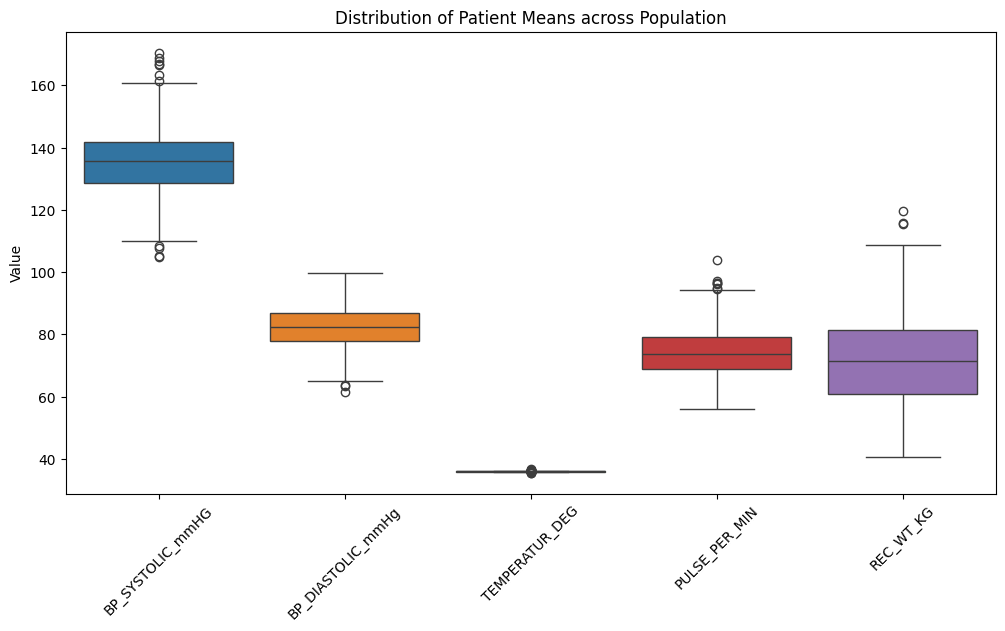

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the patient summary for easier plotting
df_plot = patient_summary.T

# Boxplot of Means to see the spread across the population
vitals = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG','PULSE_PER_MIN', 'REC_WT_KG']
plt.figure(figsize=(12, 6))
sns.boxplot(data=patient_summary[vitals].xs('mean', axis=1, level=1))
plt.title('Distribution of Patient Means across Population')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

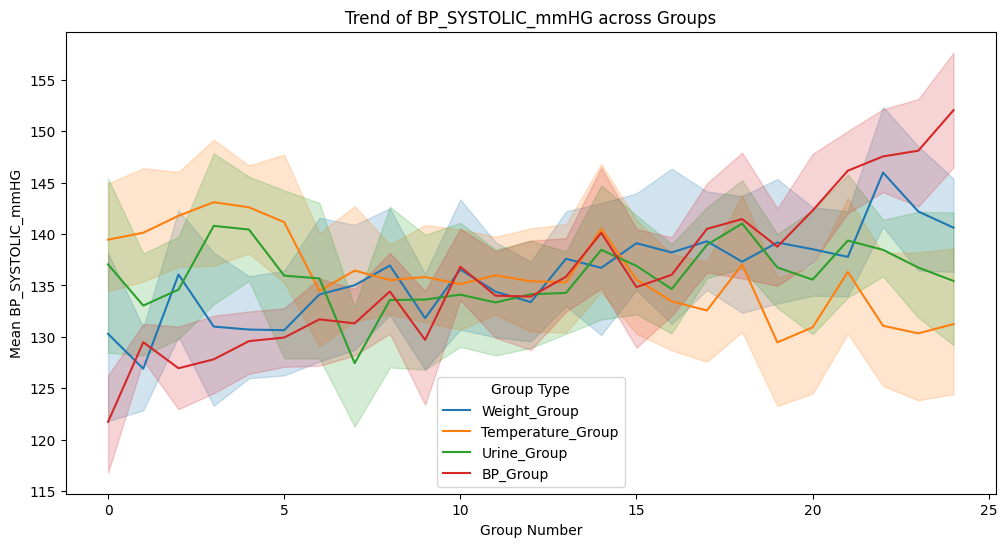

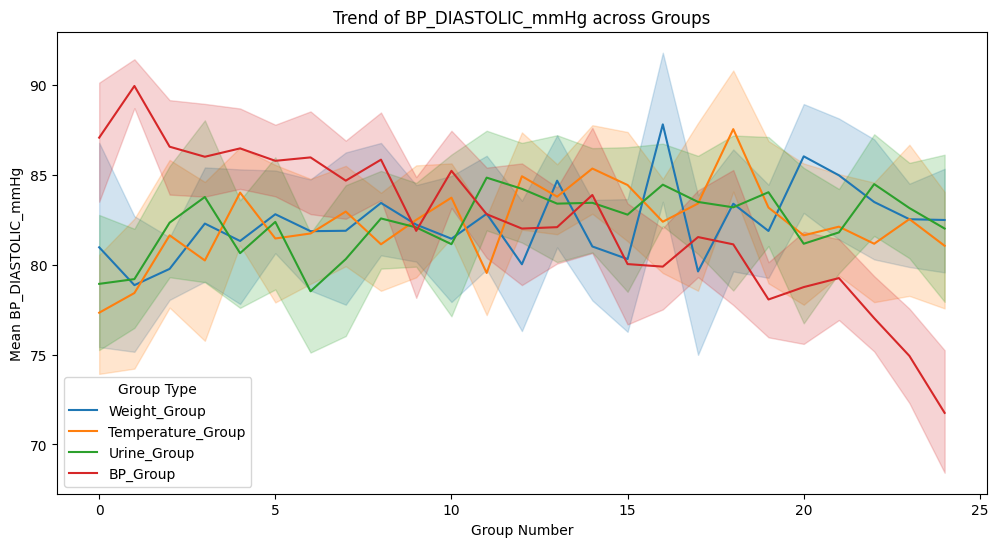

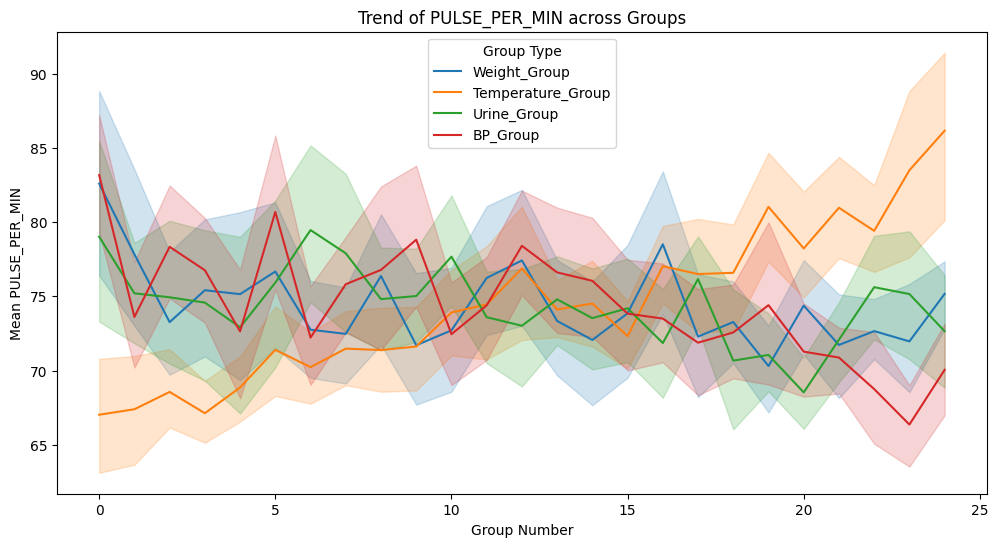

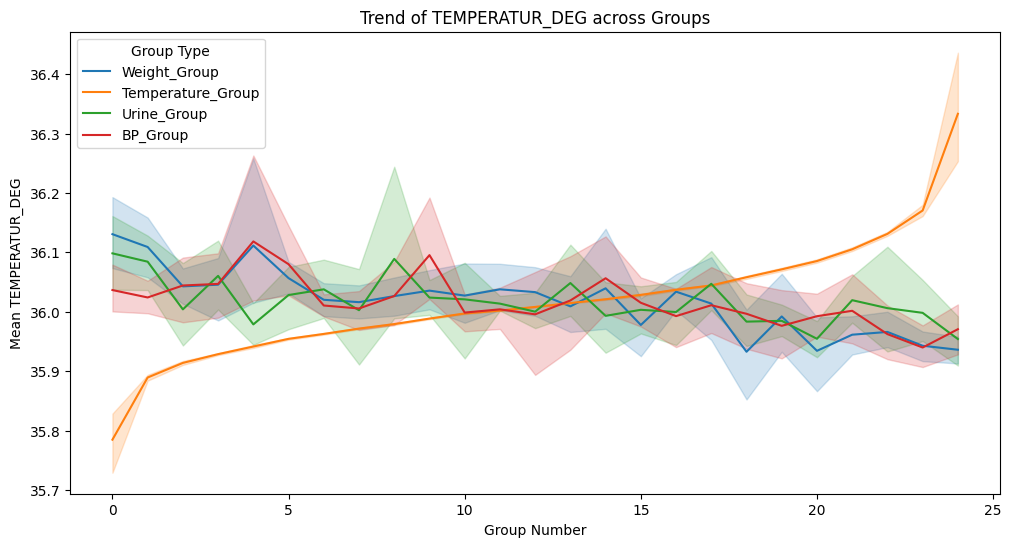

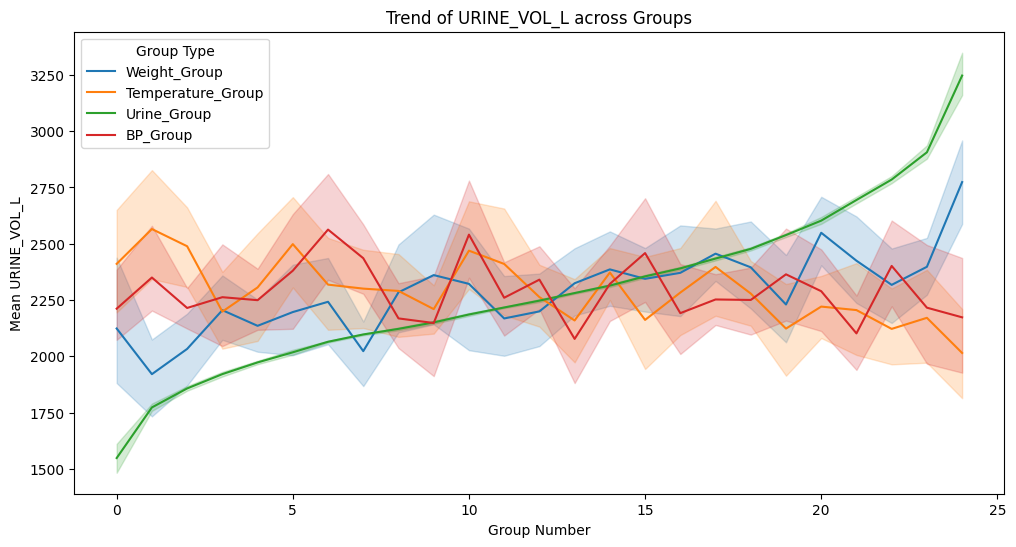

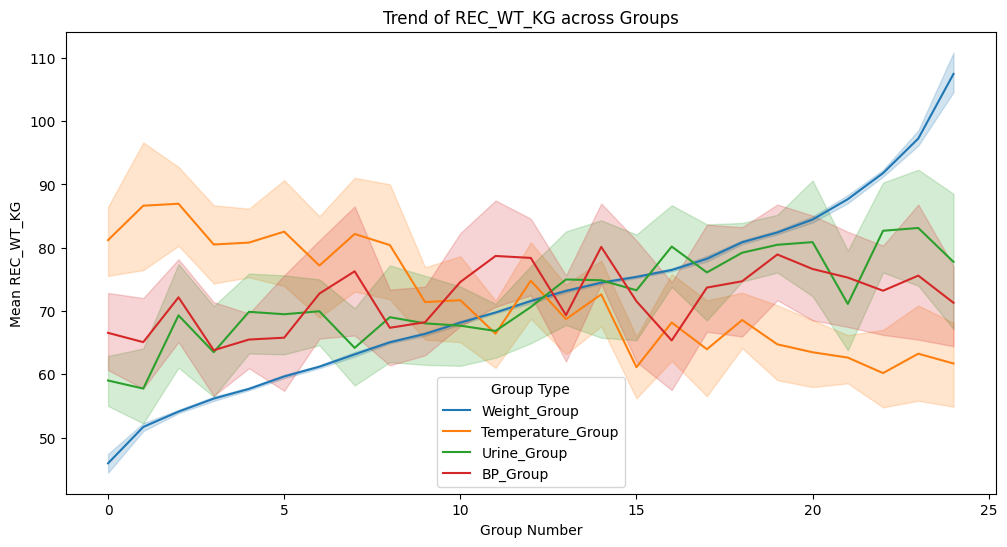

In [7]:
# Visualize the clinical trends of weight, temperature, blood pressure, and urine volume 
# Categorize the patients based on their mean weight, blood pressure, urine volume into 25 groups
patient_summary['Weight_Group'] = pd.qcut(patient_summary[('REC_WT_KG', 'mean')], q=25, labels=False)
patient_summary['Urine_Group'] = pd.qcut(patient_summary[('URINE_VOL_L', 'mean')], q=25, labels=False)
patient_summary['Temperature_Group'] = pd.qcut(patient_summary[('TEMPERATUR_DEG', 'mean')], q=25, labels=False)
patient_summary['Pulse_Group'] = pd.qcut(patient_summary[('PULSE_PER_MIN', 'mean')], q=25, labels=False)

# Categorize the patients based on their mean blood pressure into 10 groups considering 
# both systolic and diastolic and merge them in the same group
patient_summary['BP_Group'] = pd.qcut(patient_summary[('BP_SYSTOLIC_mmHG', 'mean')] / patient_summary[('BP_DIASTOLIC_mmHg', 'mean')], q=25, labels=False)

# Plot the trends for each vital sign in different plot using for loop, one for each vital sign, using the x as group number instead of patient id.
vital_signs = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'TEMPERATUR_DEG', 'URINE_VOL_L', 'REC_WT_KG']
groups = ['Weight_Group', 'Temperature_Group', 'Urine_Group', 'BP_Group']
for vital in vital_signs:
    plt.figure(figsize=(12, 6))
    for group in groups:
        sns.lineplot(x=group, y=(vital, 'mean'), data=patient_summary, label=group)
    plt.title(f'Trend of {vital} across Groups')
    plt.ylabel(f'Mean {vital}')
    plt.xlabel('Group Number')
    plt.legend(title='Group Type')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Define features (vitals) and target (Temperature)
features = ['TIME_FROM_TX_TO_ASSESSMENT', 'BP_SYSTOLIC_mmHG', 
            'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG']
target = 'TEMPERATUR_DEG'

# Fit the Model
X = df[features]
y = df[target]
model = LinearRegression()
model.fit(X, y)

# View the "Independent Impact" of each variable
coef_df = pd.DataFrame({'Variable': features, 'Impact_on_Temp': model.coef_})
print("Coefficients (Change in Temp per 1 unit change in variable):")
print(coef_df)

# Plotting: Trend over Time (Holding all other vitals constant)
# Create a range of time, but fix all other vitals at their mean
time_range = np.linspace(df['TIME_FROM_TX_TO_ASSESSMENT'].min(), 
                         df['TIME_FROM_TX_TO_ASSESSMENT'].max(), 100)
mean_vitals = df[features].mean()

# Create a 'scenario' dataframe where only Time varies
viz_df = pd.DataFrame(columns=features)
viz_df['TIME_FROM_TX_TO_ASSESSMENT'] = time_range
for col in features:
    if col != 'TIME_FROM_TX_TO_ASSESSMENT':
        viz_df[col] = mean_vitals[col]

# Predict what the Temperature would be in this scenario
viz_df['Predicted_Temp'] = model.predict(viz_df[features])

# 6. Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df['TIME_FROM_TX_TO_ASSESSMENT'], df[target], alpha=0.3, label='Actual Data')
plt.plot(viz_df['TIME_FROM_TX_TO_ASSESSMENT'], viz_df['Predicted_Temp'], 
         color='red', linewidth=3, label='Trend (Vitals held constant)')
plt.title('Predicted Temperature Trend Over Time\n(All Other Vital Signs Held Constant at Mean)')
plt.xlabel('Time from TX to Assessment')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

In [11]:
print(df.head(5))

  Patient_ID TIME_FROM_TX_TO_ASSESSMENT ANONYM_ASSESSMENT_DATE  \
0      P1000                    84 days                 3/1/04   
1      P1000                    89 days                 3/1/04   
2      P1000                   101 days                 3/1/04   
3      P1000                   109 days                 4/1/04   
4      P1000                   117 days                 4/1/04   

   BP_SYSTOLIC_mmHG  BP_DIASTOLIC_mmHg  TEMPERATUR_DEG  PULSE_PER_MIN  \
0             168.0              121.0           36.24           86.0   
1             132.0               95.0           36.18           87.0   
2             136.0              100.0           36.10           91.0   
3             141.0              103.0           36.01           67.0   
4             141.0               98.0           36.01           68.0   

   URINE_VOL_L  REC_WT_KG  
0      2126.29       55.0  
1      2121.47       55.0  
2      2142.20       58.0  
3      2280.01       60.0  
4      2263.28       61.

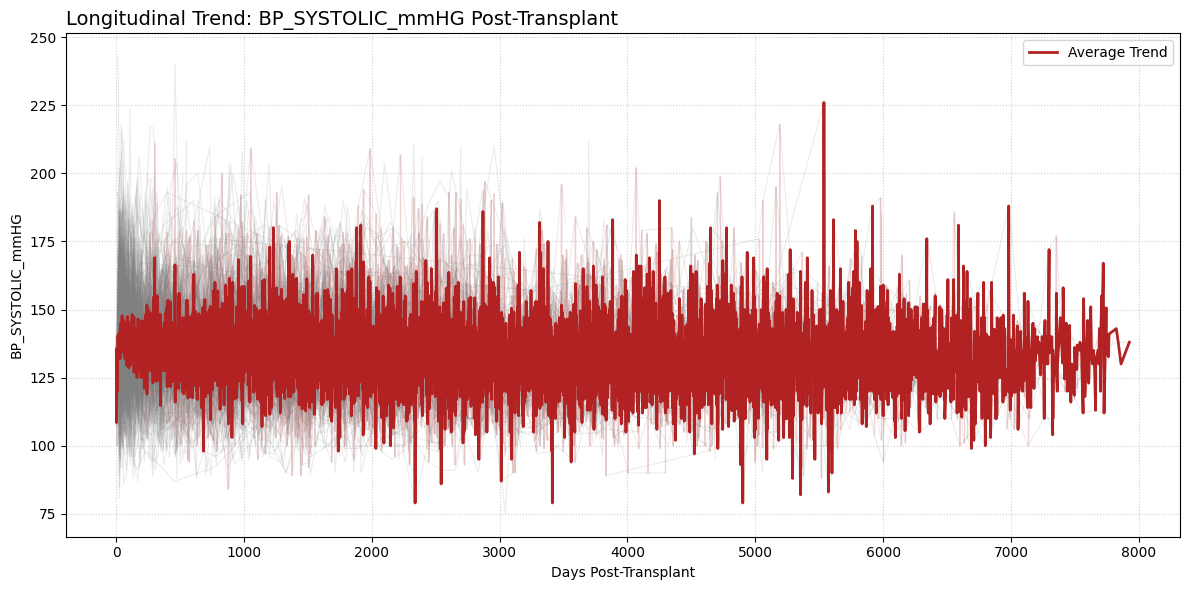

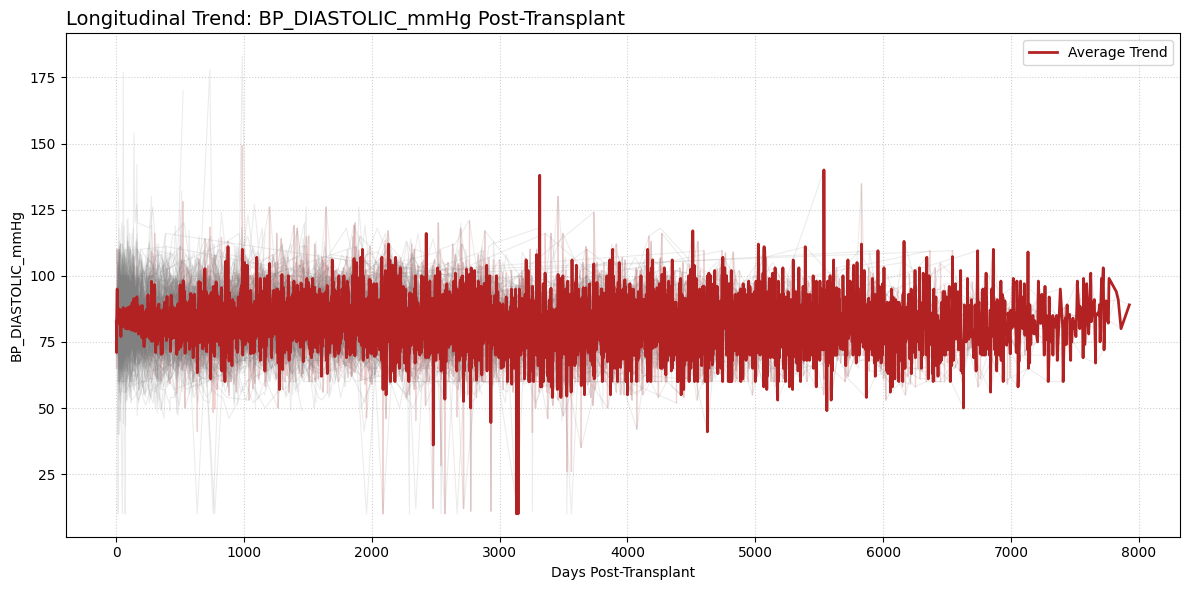

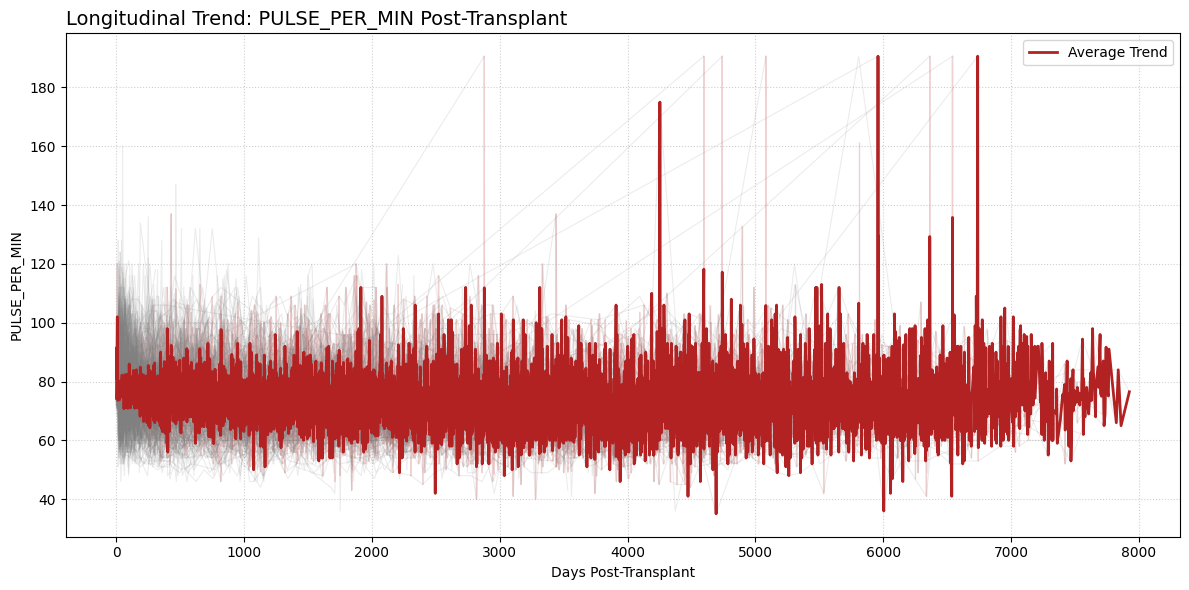

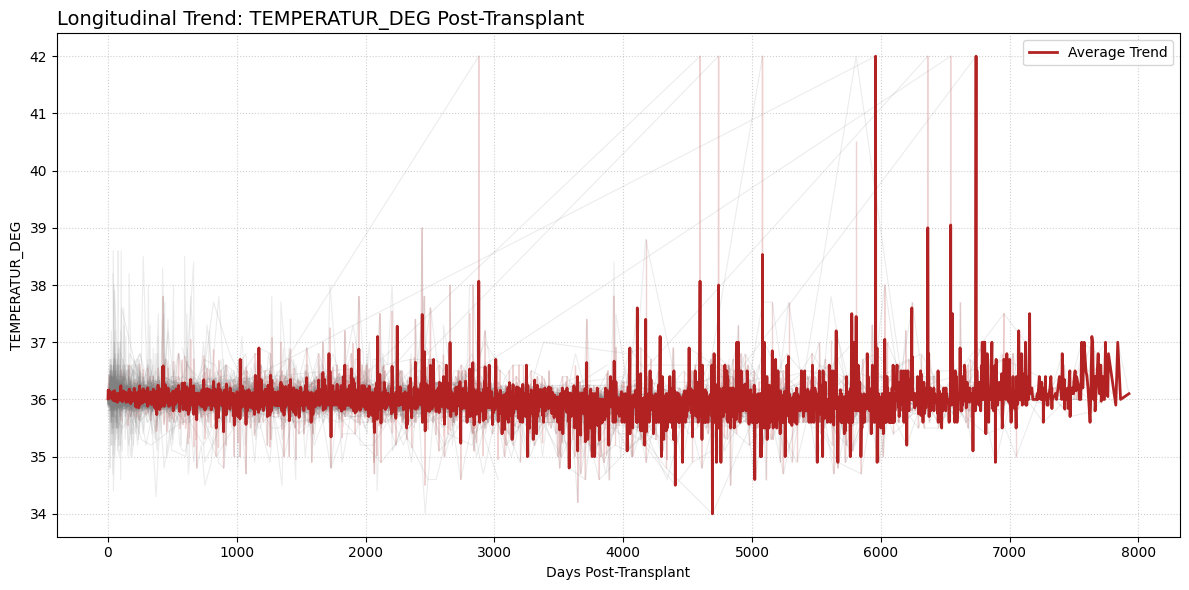

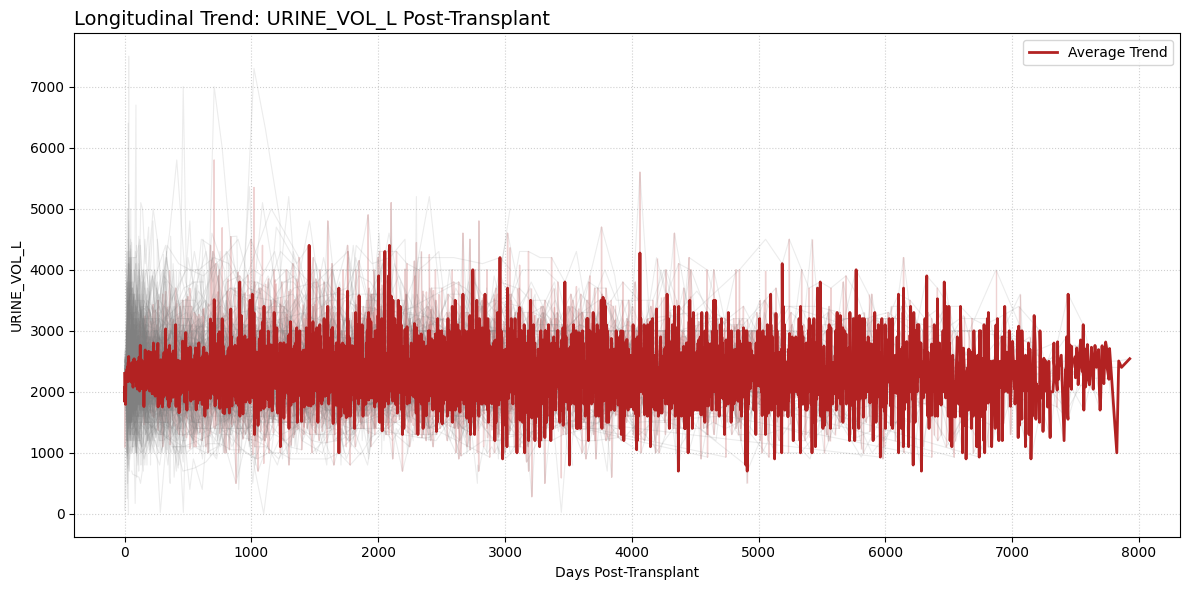

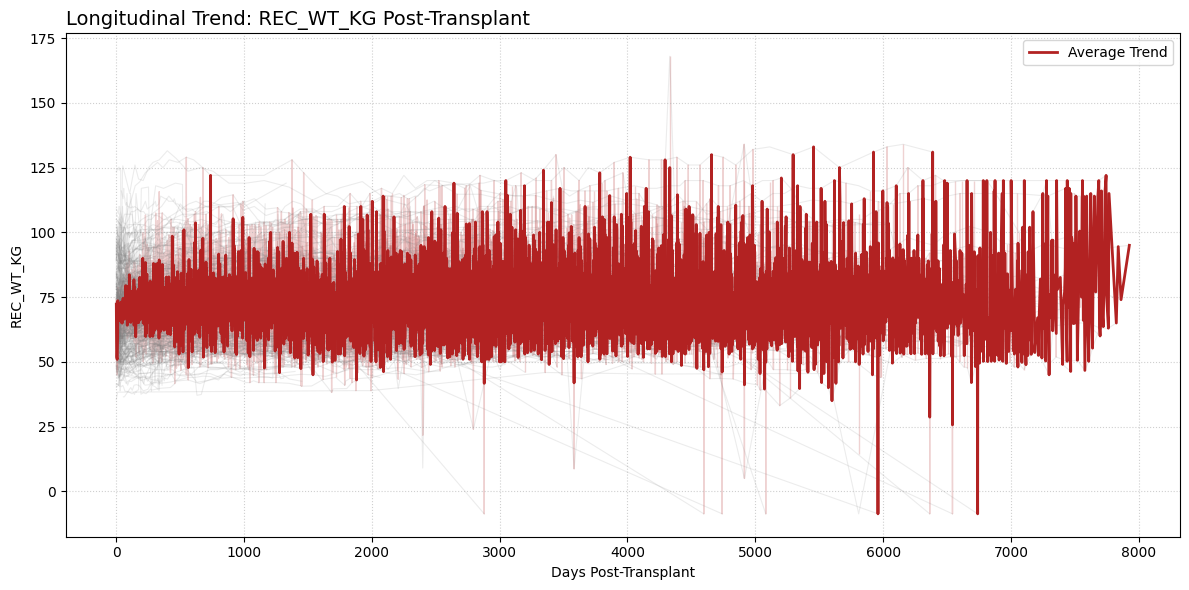

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. PRE-PROCESSING: Convert "84 days" string to integer 84
# This ensures the X-axis is a continuous scale of time.
df['Days_Numeric'] = df['TIME_FROM_TX_TO_ASSESSMENT'].astype(str).str.extract('(\d+)').astype(float)

# 2. DEFINING THE VITALS
vital_signs = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'TEMPERATUR_DEG', 'URINE_VOL_L', 'REC_WT_KG']

# 3. GENERATING THE PLOTS
for vital in vital_signs:
    plt.figure(figsize=(12, 6))
    
    # INDIVIDUAL TRAJECTORIES (The Spaghetti)
    # Each 'Patient_ID' gets its own individual line.
    sns.lineplot(
        data=df, 
        x='Days_Numeric', 
        y=vital, 
        units='Patient_ID', 
        estimator=None, 
        color='gray', 
        alpha=0.15, 
        linewidth=0.8
    )
    
    # POPULATION TREND (The Marinara)
    # This draws a single bold line showing the average clinical path.
    sns.lineplot(
        data=df, 
        x='Days_Numeric', 
        y=vital, 
        color='firebrick', 
        linewidth=2, 
        label='Average Trend'
    )

    plt.title(f'Longitudinal Trend: {vital} Post-Transplant', fontsize=14, loc='left')
    plt.xlabel('Days Post-Transplant')
    plt.ylabel(vital)
    plt.grid(True, which='major', linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

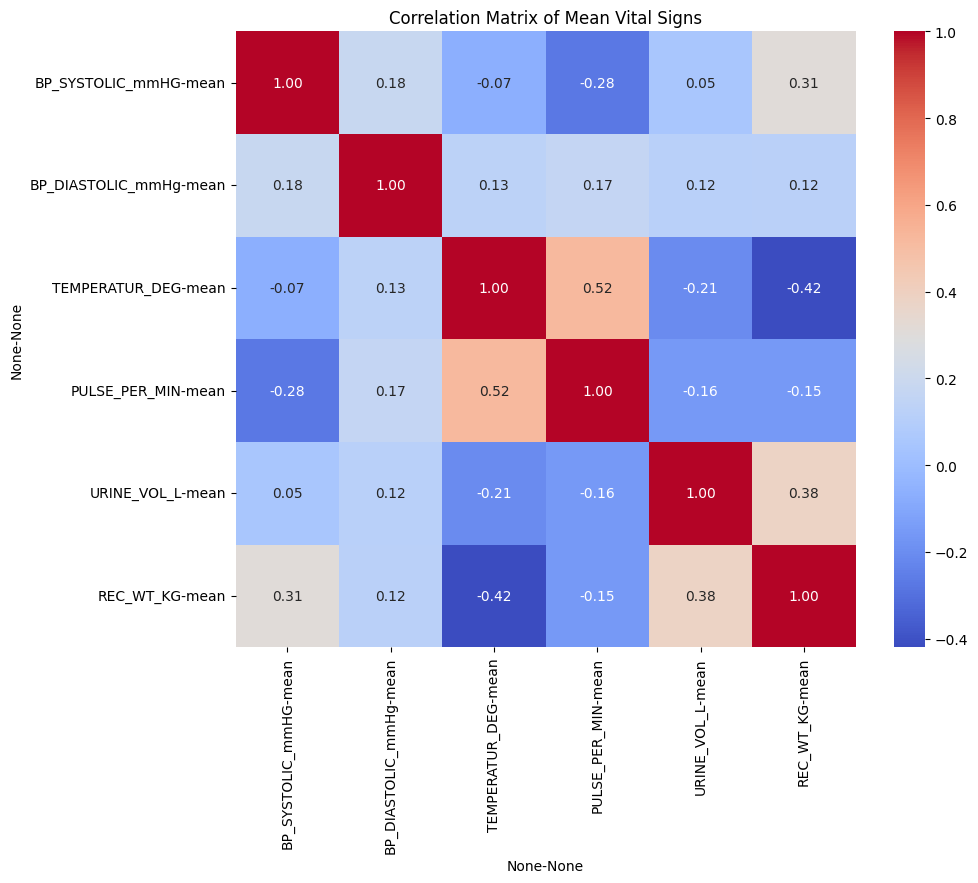

In [11]:
# Calculate the correlation between all the vital signs
correlation_matrix = patient_summary[[('BP_SYSTOLIC_mmHG', 'mean'), ('BP_DIASTOLIC_mmHg', 'mean'), 
                                      ('TEMPERATUR_DEG', 'mean'), ('PULSE_PER_MIN', 'mean'), 
                                      ('URINE_VOL_L', 'mean'), ('REC_WT_KG', 'mean')]].corr()


# Visualize the correlation using a heatmap shows the correlation between the mean 
# of each vital sign and each vital sign, not the mean of the whole group.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Mean Vital Signs')
plt.show()


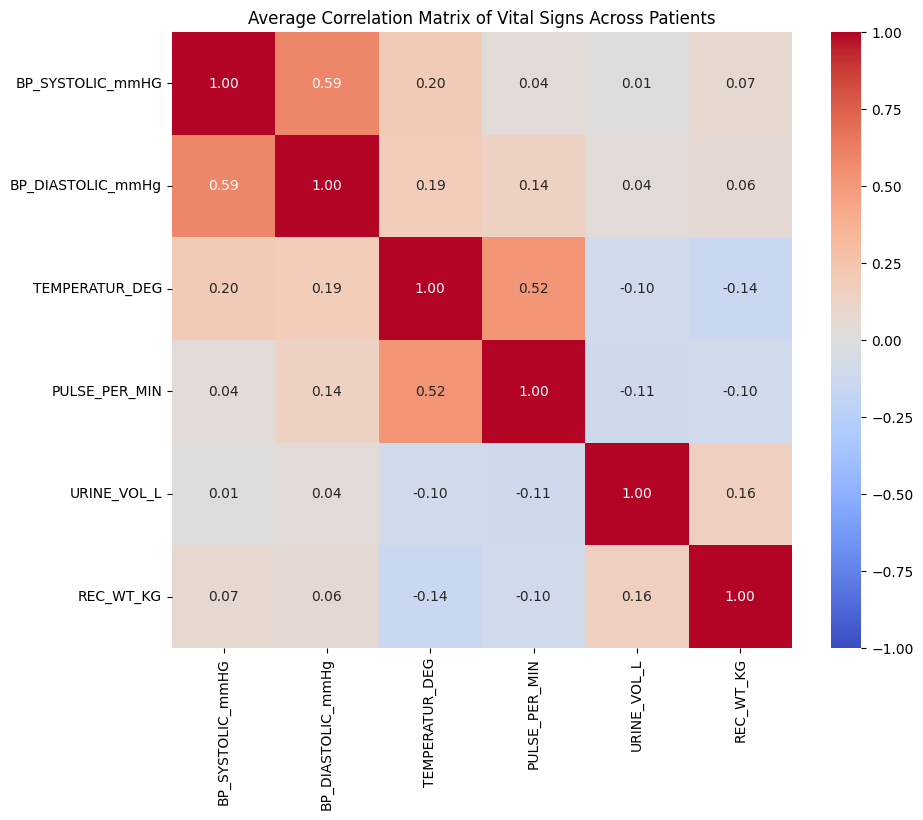

In [13]:
# Calculate how the correlation between the vital signs change through time 
# for each patient, and then calculate the average correlation across all patients for each pair of vital signs, and visualize it using a heatmap.
# 1. Define the columns we care about
cols = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG', 
        'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG']

# 2. Calculate correlations per patient and stack them into one big DataFrame
# .corr() handles NaNs internally, but we use .groupby().corr() 
all_corrs = df.groupby('Patient_ID')[cols].corr()

# 3. Group by the level (the vital sign name) and take the mean
# skipna=True is the default, so it will average all available valid correlations
average_correlation = all_corrs.groupby(level=1).mean()

# Reorder to match your original list (groupby might alphabetize)
average_correlation = average_correlation.reindex(index=cols, columns=cols)

# 4. Visualize
plt.figure(figsize=(10, 8))
# Added vmin/vmax to ensure the color scale is centered and visible
sns.heatmap(average_correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Average Correlation Matrix of Vital Signs Across Patients')
plt.show()


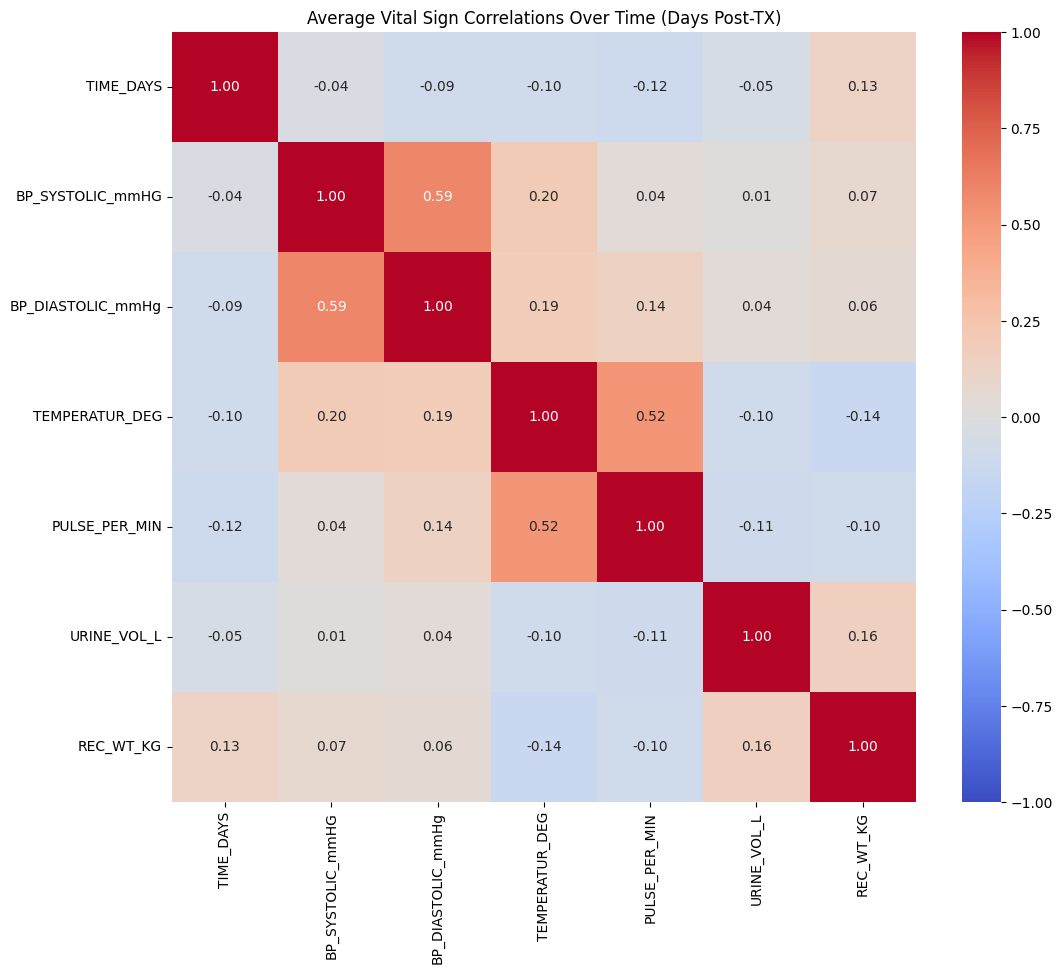

In [15]:
# 1. Clean the Time column: Extract only the numbers and convert to float/int
# We use .str.extract('(\d+)') to grab the digits before ' days'
df['TIME_DAYS'] = df['TIME_FROM_TX_TO_ASSESSMENT'].astype(str).str.extract('(\d+)').astype(float)

# 2. Define your columns (now using the numeric TIME_DAYS)
vitals = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG', 
          'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG']
cols = ['TIME_DAYS'] + vitals

# 3. Calculate per-patient correlations
all_corrs = df.groupby('Patient_ID')[cols].corr()

# 4. Average the correlations across all patients
# skipna=True ensures patients with missing data don't break the average
avg_corr = all_corrs.groupby(level=1).mean().reindex(index=cols, columns=cols)

# 5. Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(avg_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title('Average Vital Sign Correlations Over Time (Days Post-TX)')
plt.show()

In [ ]:
# Also, let me know whether patients show stabilization of vitals in 
# the first months after transplant. If yes, what's the general trend?


Skipping BP_SYSTOLIC_mmHG: No valid data found.
Skipping BP_DIASTOLIC_mmHg: No valid data found.
Skipping PULSE_PER_MIN: No valid data found.
Skipping URINE_VOL_L: No valid data found.
Skipping REC_WT_KG: No valid data found.


In [ ]:


# Do you find some correlations between Clinical Variables

# Which vital sign can be a key indicator of graft function?
